# Reverse or rotate the baroclinic wave test case

In [1]:
using SpeedyWeather, CairoMakie, NCDatasets, Dates, OrderedCollections

# Baseline
Original code from

https://speedyweather.github.io/SpeedyWeatherDocumentation/dev/examples_3D#Jablonowski-Williamson-baroclinic-wave

In [ ]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

model = PrimitiveDryModel(spectral_grid; orography, land, ocean)
simulation = initialize!(model)
run!(simulation, period=Day(10))

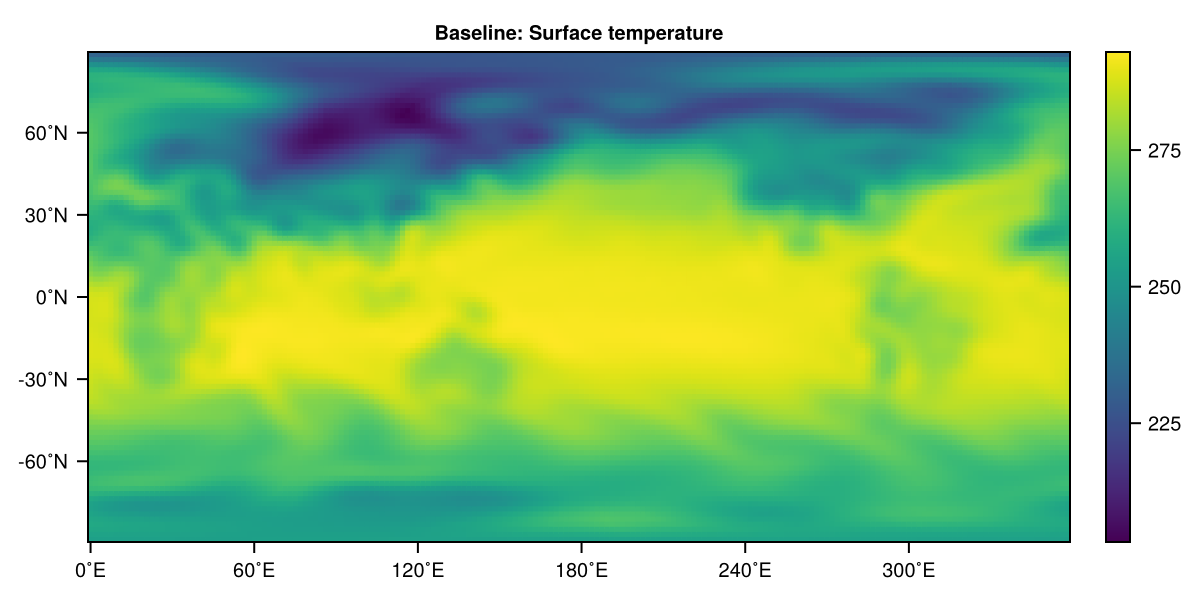

In [3]:
temp = simulation.variables.grid.temperature[:, end]
heatmap(temp, title="Baseline: Surface temperature")

# Identify which variables to rotate/reverse

All the prognostic variables have to be reversed, no memory should reside in the other variable groups

In [4]:
simulation.variables

Variables{@NamedTuple{...}, ...} (19.46 MB)
├ prognostic (1.41 MB)
│ ├ clock: Clock{DateTime, Second, Int64, Millisecond}
│ ├ scale: Base.RefValue{Float64}
│ ├ vorticity: 989×8×2 LowerTriangularArray{ComplexF64, 3, Array{...}}
│ ├ divergence: 989×8×2 LowerTriangularArray{ComplexF64, 3, Array{...}}
│ ├ temperature: 989×8×2 LowerTriangularArray{ComplexF64, 3, Array{...}}
│ ├ pressure: 989×2 LowerTriangularArray{ComplexF64, 2, Array{...}}
│ ├ land
│ │ ├ soil_temperature: 9408×2, 96-ring OctaminimalGaussianField{Float64, 2...
│ │ ├ soil_moisture: 9408×2, 96-ring OctaminimalGaussianField{Float64, 2} a...
│ │ └ snow_depth: 9408-element, 96-ring OctaminimalGaussianField{Float64, 1...
│ └ ocean
│   ├ sea_surface_temperature: 9408-element, 96-ring OctaminimalGaussianFie...
│   └ sea_ice_concentration: 9408-element, 96-ring OctaminimalGaussianField...
├ grid (6.25 MB)
│ ├ vorticity: 9408×8, 96-ring OctaminimalGaussianField{Float64, 2} as Arra...
│ ├ u: 9408×8, 96-ring OctaminimalGaussianField{Fl

# Rotate longitude

Start creating another (at first identical) model and simulation

In [ ]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

# but rename model and simulation to avoid overwriting
model_rotate_lon = PrimitiveDryModel(spectral_grid; orography=deepcopy(orography), land=deepcopy(land), ocean=deepcopy(ocean))
simulation_rotate_lon = initialize!(model_rotate_lon)

In [6]:
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))

    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)

    λ = 0
    # rotate longitude by π: shift solar hour angle by half a day
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc + NF(π)

    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)

    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

In [7]:
# rotate variables
(; variables) = simulation_rotate_lon
(; vorticity, divergence, temperature, pressure) = variables.prognostic
(; land, ocean) = variables.prognostic

for k in eachmatrix(vorticity)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(vorticity, :, k), 180)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(divergence, :, k), 180)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(temperature, :, k), 180)
end

for k in eachmatrix(pressure)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(pressure, :, k), 180)
end

# rotate land prognostic variables
SpeedyWeather.rotate!(land.soil_temperature, 180)
SpeedyWeather.rotate!(land.soil_moisture, 180)
SpeedyWeather.rotate!(land.snow_depth, 180)

# rotate ocean prognostic variables
SpeedyWeather.rotate!(ocean.sea_surface_temperature, 180)
SpeedyWeather.rotate!(ocean.sea_ice_concentration, 180);

In [8]:
# rotate boundary conditions
SpeedyWeather.rotate!(simulation_rotate_lon.model.land_sea_mask.mask, 180)
SpeedyWeather.rotate!(simulation_rotate_lon.model.orography.surface_geopotential, 180)
SpeedyWeather.rotate!(simulation_rotate_lon.model.orography.orography, 180)

SpeedyWeather.rotate!(simulation_rotate_lon.model.land.vegetation.high_cover, 180)
SpeedyWeather.rotate!(simulation_rotate_lon.model.land.vegetation.low_cover, 180);

In [9]:
simulation_rotate_lon.model

PrimitiveDryModel{...} <: PrimitiveDry (4.93 MB)
├ spectral_grid::SpectralGrid{CPU{KernelAbstractions.CPU}, Spectrum{CPU{Ker...
├ architecture::CPU{KernelAbstractions.CPU}
├ dynamics::Bool
├ geometry::Geometry{SpectralGrid{CPU{KernelAbstractions.CPU}, Spectrum{CPU...
├ planet::Earth{Float64, Second, DateTime, Bool}
├ atmosphere::EarthDryAtmosphere{Float64}
├ coriolis::Coriolis{Vector{Float64}}
├ geopotential::Geopotential{Vector{Float64}}
├ adiabatic_conversion::AdiabaticConversion{Vector{Float64}}
├ particle_advection::Nothing
├ initial_conditions::@NamedTuple{vordiv::ZonalWind{Float64}, pres::Pressur...
├ forcing::Nothing
├ drag::SpeedLimitDrag{Float64}
├ random_process::Nothing
├ tracers::Dict{Symbol, Tracer}
├ dynamics_only::Bool
├ orography::EarthOrography{Float64, Field{Float64, 1, Vector{Float64}, Oct...
├ land_sea_mask::EarthLandSeaMask{Float64, Field{Float64, 1, Vector{Float64...
├ ocean::SlabOcean{Float64}
├ sea_ice::ThermodynamicSeaIce{Float64}
├ land::LandModel{LandGeometry

 100% Time: 0:00:16 (2000-01-11, 139.63 years/day,  77 m/s, [ -81,   20] ˚C)


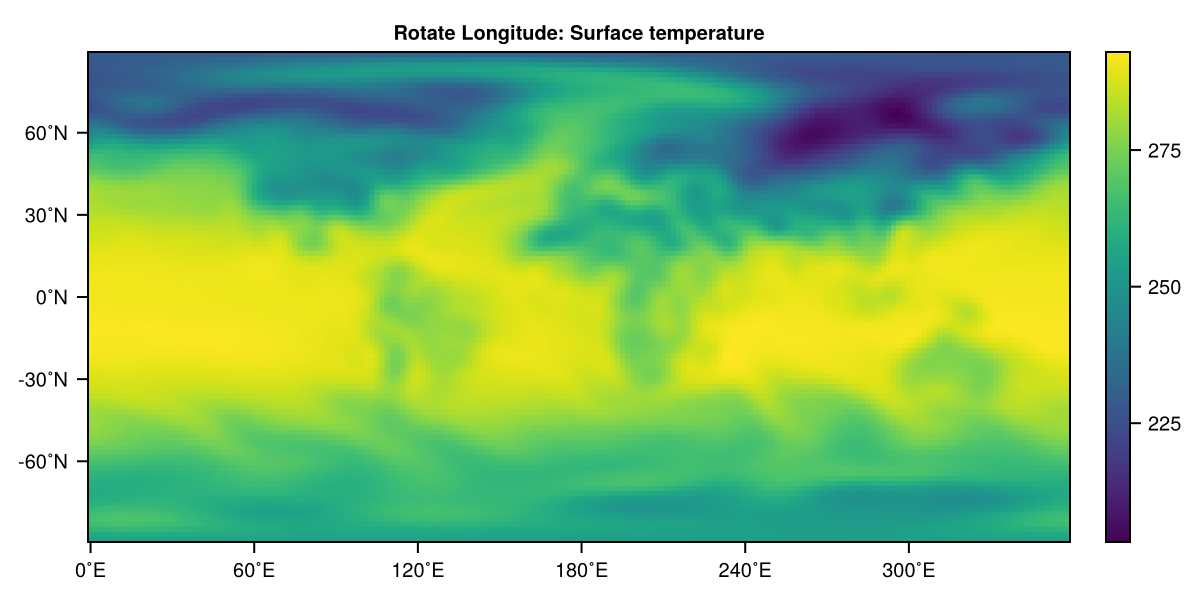

In [10]:
run!(simulation_rotate_lon, period=Day(10))

temp_rot_lon = simulation_rotate_lon.variables.grid.temperature[:, end]
heatmap(temp_rot_lon, title="Rotate Longitude: Surface temperature")

## Error map

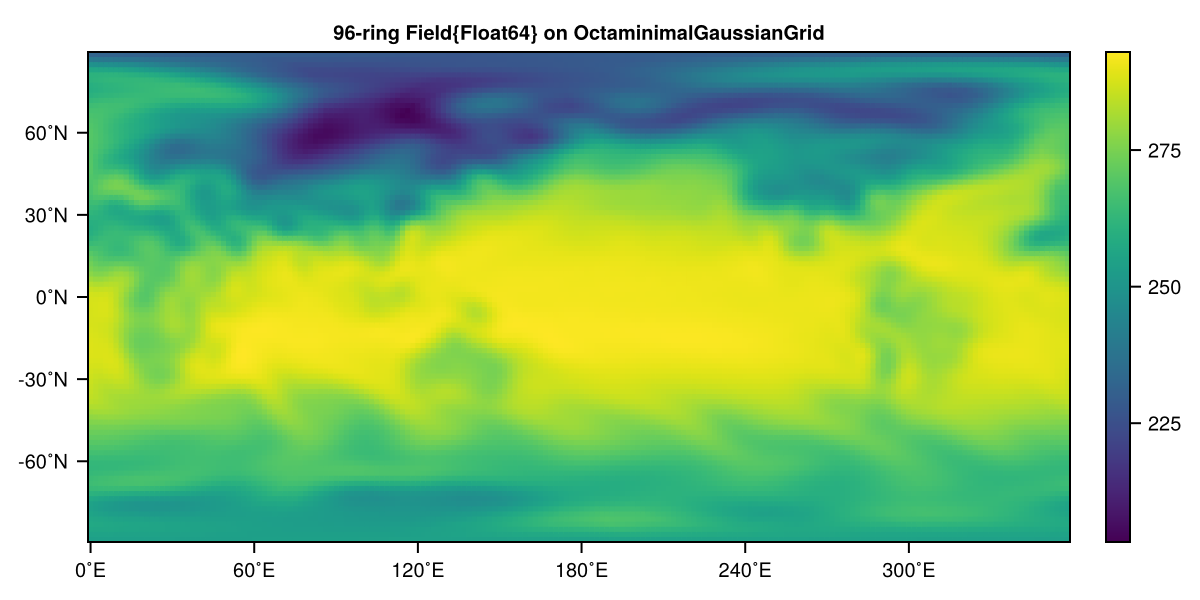

In [11]:
temp_rotated_back = SpeedyWeather.rotate!(deepcopy(temp_rot_lon), -180)
heatmap(temp_rotated_back)

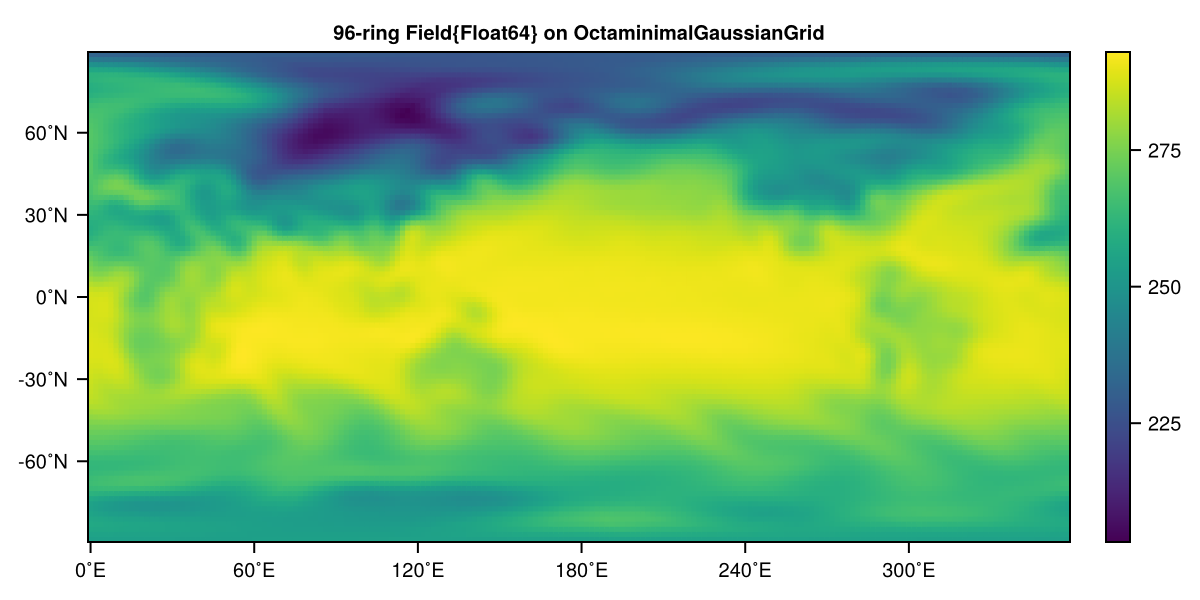

In [12]:
heatmap(temp)

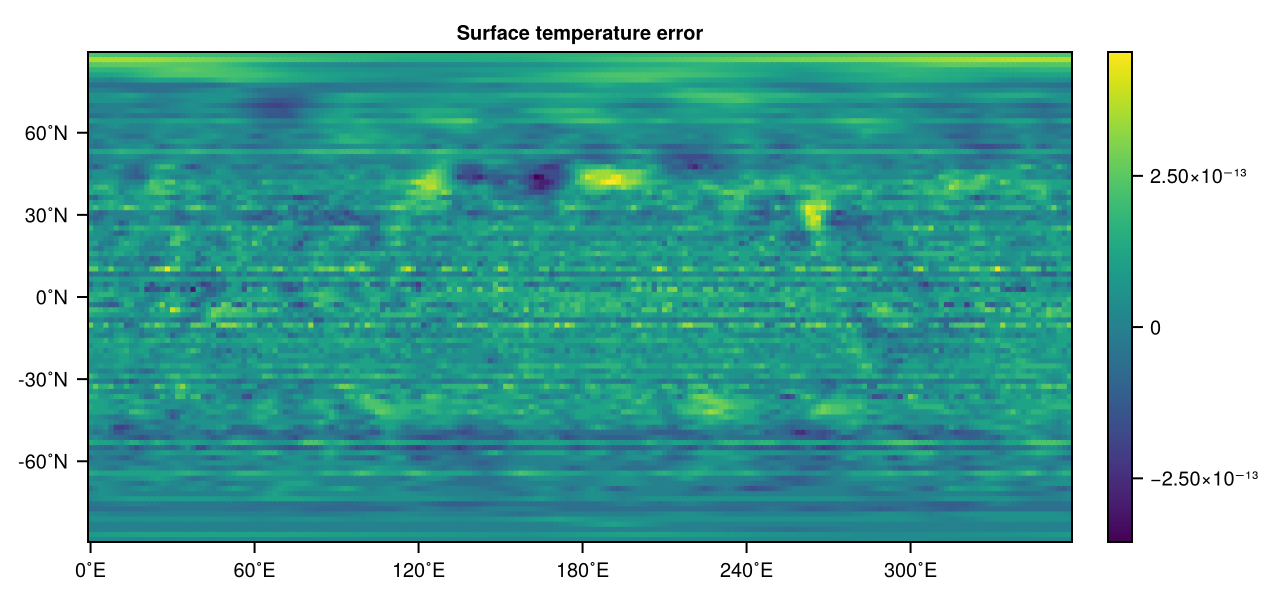

In [13]:
heatmap(temp_rotated_back - temp, title="Surface temperature error")

# Reverse latitude

In [ ]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

# but rename model and simulation to avoid overwriting
model_reverse_lat = PrimitiveDryModel(spectral_grid; orography=deepcopy(orography), land=deepcopy(land), ocean=deepcopy(ocean))
simulation_reverse_lat = initialize!(model_reverse_lat)

In [16]:
# reverse variables
(; variables) = simulation_reverse_lat
(; vorticity, divergence, temperature, pressure) = variables.prognostic
(; land, ocean) = variables.prognostic

for k in eachmatrix(vorticity)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lat)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lat)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lat)
end

# and as v -> -v, y -> -y also vorticity ζ -> -ζ
vorticity .*= -1

for k in eachmatrix(pressure)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lat)
end

# reverse land prognostic variables
SpeedyWeather.reverse!(land.soil_temperature, dims=:lat)
SpeedyWeather.reverse!(land.soil_moisture, dims=:lat)
SpeedyWeather.reverse!(land.snow_depth, dims=:lat)

# reverse ocean prognostic variables
SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lat)
SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lat);

In [17]:
# reverse boundary conditions
SpeedyWeather.reverse!(simulation_reverse_lat.model.land_sea_mask.mask, dims=:lat)
SpeedyWeather.reverse!(simulation_reverse_lat.model.orography.surface_geopotential, dims=:lat)
SpeedyWeather.reverse!(simulation_reverse_lat.model.orography.orography, dims=:lat);

SpeedyWeather.reverse!(simulation_reverse_lat.model.land.vegetation.high_cover, dims=:lat)
SpeedyWeather.reverse!(simulation_reverse_lat.model.land.vegetation.low_cover, dims=:lat);

In [18]:
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},      # ← AbstractField, not AbstractGrid
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))

    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)

    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc

    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)

    # reverse latitude: negate sinlat only (cos(-φ) = cos(φ))
    sinlat_rev = -sinlat

    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat_rev, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end


 100% Time: 0:00:16 (2000-01-11, 146.18 years/day,  77 m/s, [ -81,   20] ˚C)


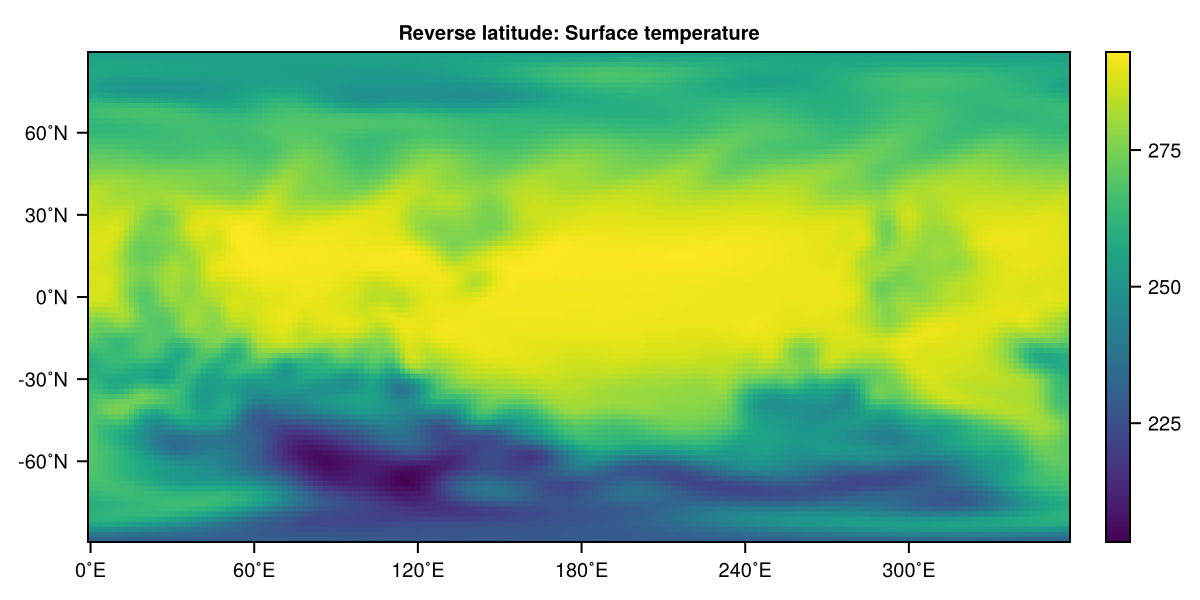

In [19]:
# run and visualise
run!(simulation_reverse_lat, period=Day(10))

temp_rev_lat = simulation_reverse_lat.variables.grid.temperature[:, end]
heatmap(temp_rev_lat, title="Reverse latitude: Surface temperature")

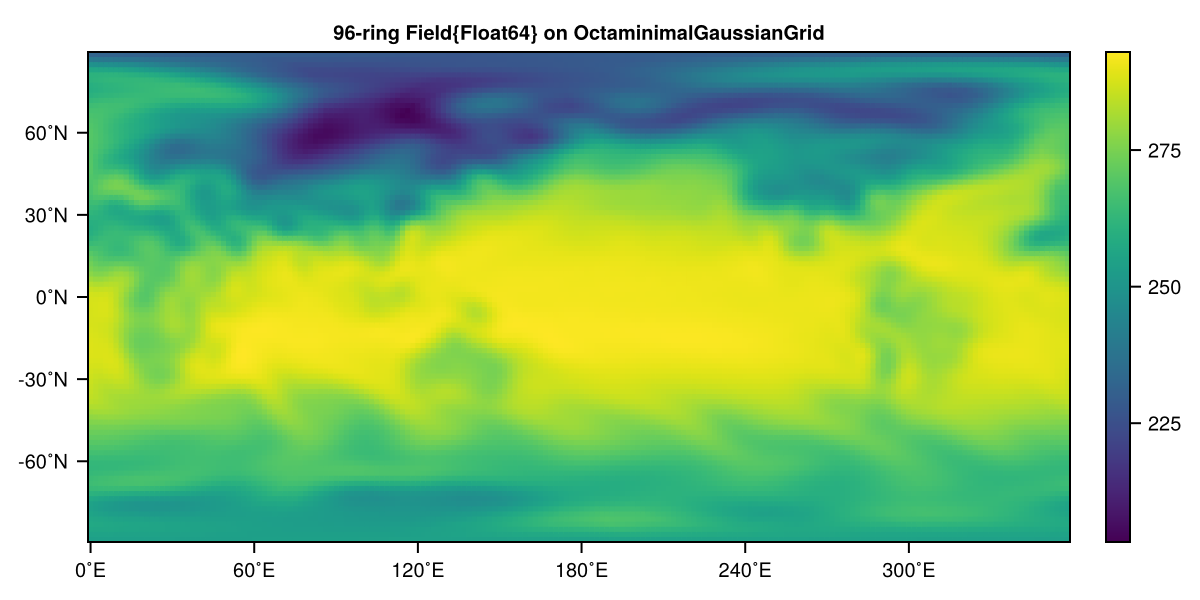

In [20]:
temp_reversed_lat_back = reverse!(deepcopy(temp_rev_lat), dims=:lat)
heatmap(temp_reversed_lat_back)

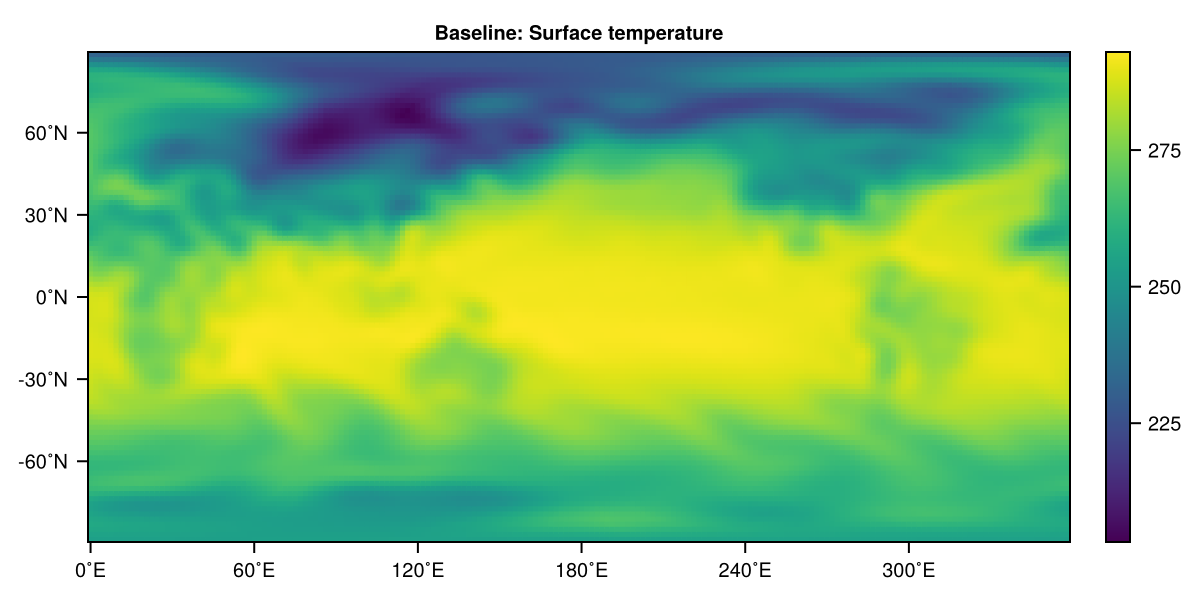

In [21]:
heatmap(temp, title="Baseline: Surface temperature")

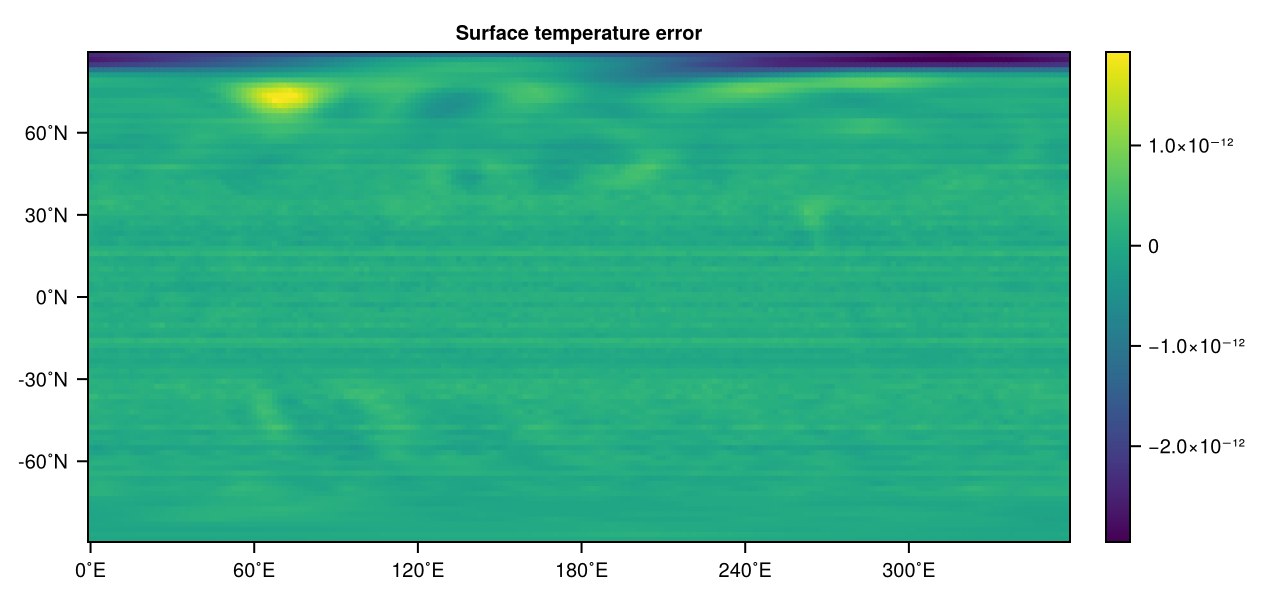

In [22]:
heatmap(temp_reversed_lat_back - temp, title="Surface temperature error")

# Reverse longitude

In [ ]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

# but rename model and simulation to avoid overwriting
model_reverse_lon = PrimitiveDryModel(spectral_grid; orography=deepcopy(orography), land=deepcopy(land), ocean=deepcopy(ocean))
simulation_reverse_lon = initialize!(model_reverse_lon)

In [24]:
# reverse variables
(; variables) = simulation_reverse_lon
(; vorticity, divergence, temperature, pressure) = variables.prognostic
(; land, ocean) = variables.prognostic

for k in eachmatrix(vorticity)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lon)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lon)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lon)
end

# and as u -> -u, x -> -x also vorticity ζ -> -ζ, divergence remains unchanged
vorticity .*= -1

for k in eachmatrix(pressure)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lon)
end

# reverse land prognostic variables
SpeedyWeather.reverse!(land.soil_temperature, dims=:lon)
SpeedyWeather.reverse!(land.soil_moisture, dims=:lon)
SpeedyWeather.reverse!(land.snow_depth, dims=:lon)

# reverse ocean prognostic variables
SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lon)
SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lon);

In [25]:
# reverse boundary conditions
SpeedyWeather.reverse!(simulation_reverse_lon.model.land_sea_mask.mask, dims=:lon)
SpeedyWeather.reverse!(simulation_reverse_lon.model.orography.surface_geopotential, dims=:lon)
SpeedyWeather.reverse!(simulation_reverse_lon.model.orography.orography, dims=:lon)

# change the coriolis parameter directly instead of model.planet.rotation
# as ZonalRidge depends on that which however we do not want to change sign!
simulation_reverse_lon.model.coriolis.f .*= -1;

SpeedyWeather.reverse!(simulation_reverse_lon.model.land.vegetation.high_cover, dims=:lon)
SpeedyWeather.reverse!(simulation_reverse_lon.model.land.vegetation.low_cover, dims=:lon);

In [26]:
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))

    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)

    λ = 0
    # reverse longitude λ → -λ: negate solar hour angle
    solar_hour_angle_0E = -(SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc)

    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)

    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end


 100% Time: 0:00:16 (2000-01-11, 143.80 years/day,  76 m/s, [ -81,   20] ˚C)


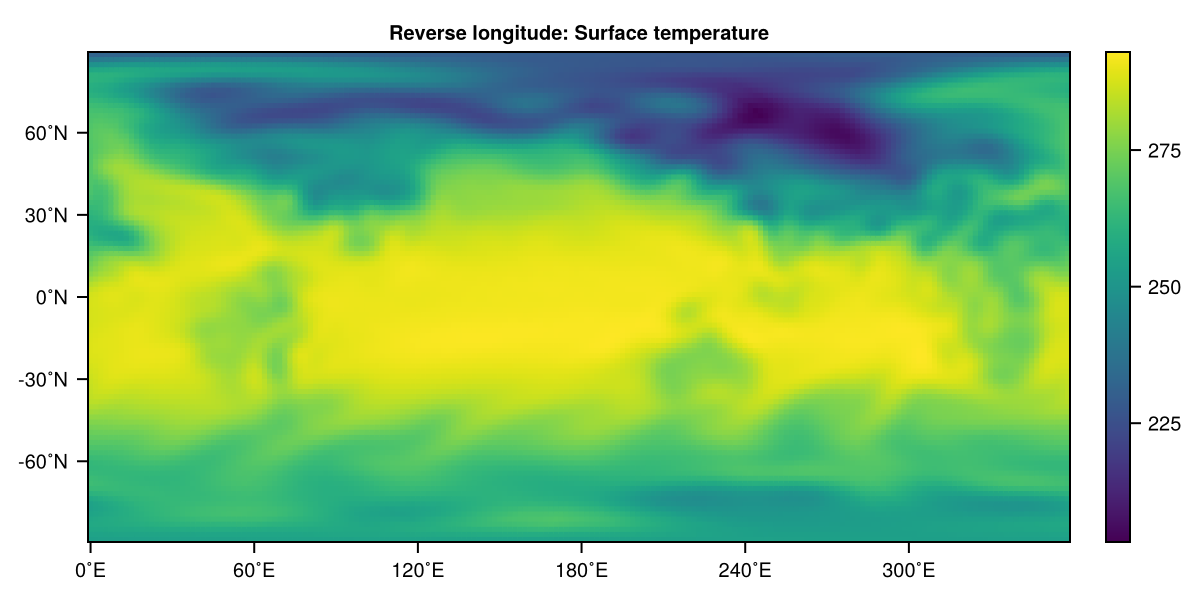

In [27]:
# run and visualise
run!(simulation_reverse_lon, period=Day(10))

temp_rev_lon = simulation_reverse_lon.variables.grid.temperature[:, end]
heatmap(temp_rev_lon, title="Reverse longitude: Surface temperature")

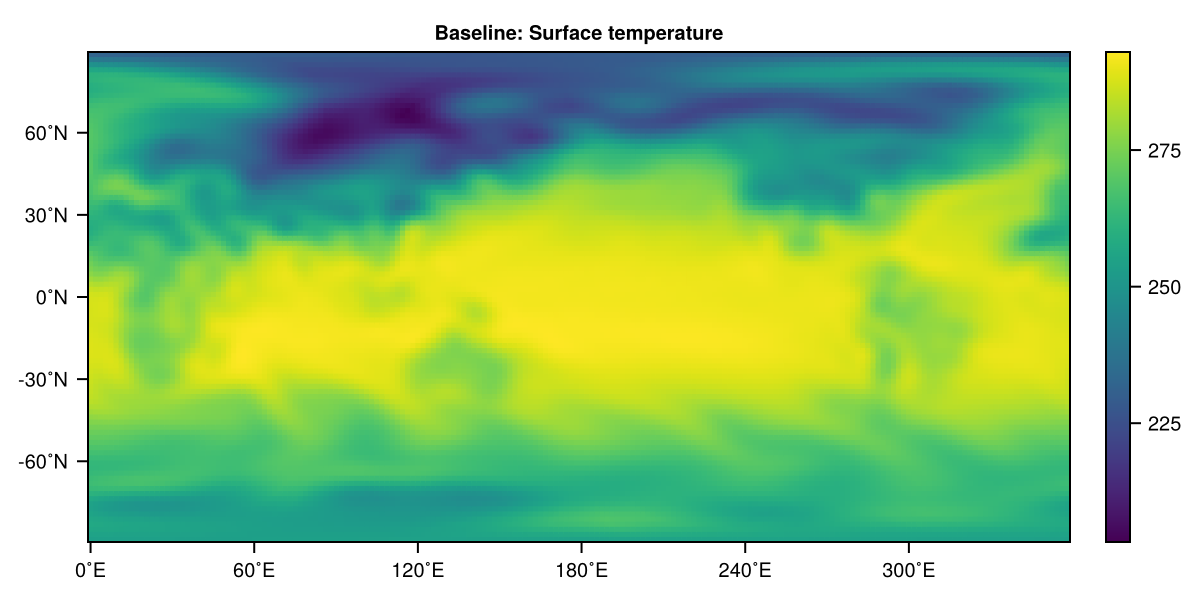

In [28]:
heatmap(temp, title="Baseline: Surface temperature")

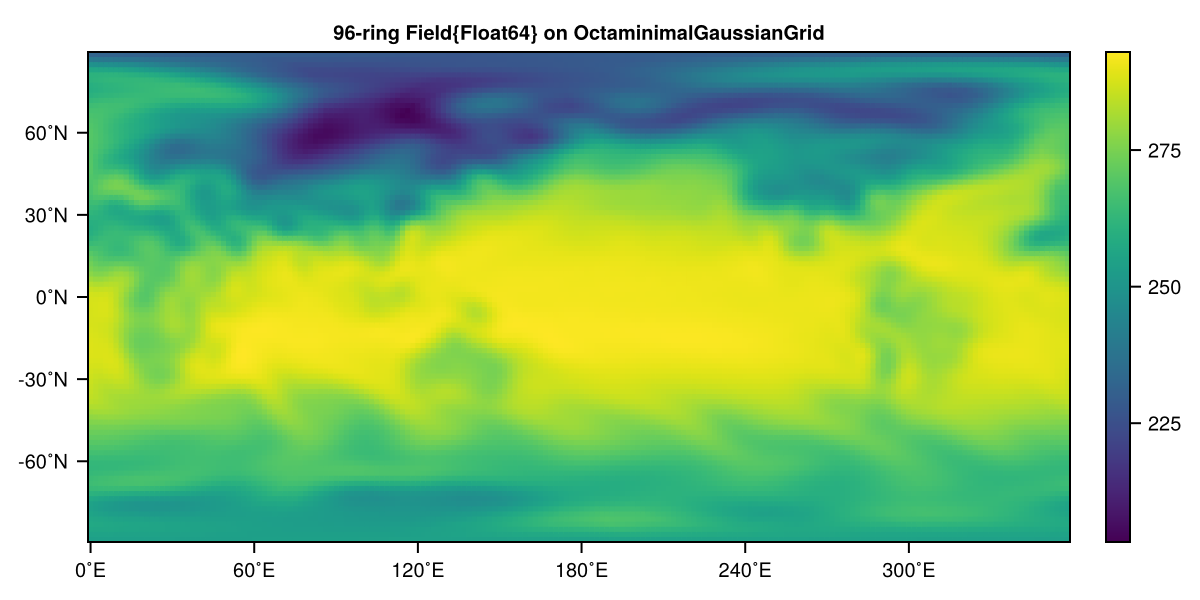

In [29]:
temp_reversed_lon_back = reverse!(deepcopy(temp_rev_lon), dims=:lon)
heatmap(temp_reversed_lon_back)

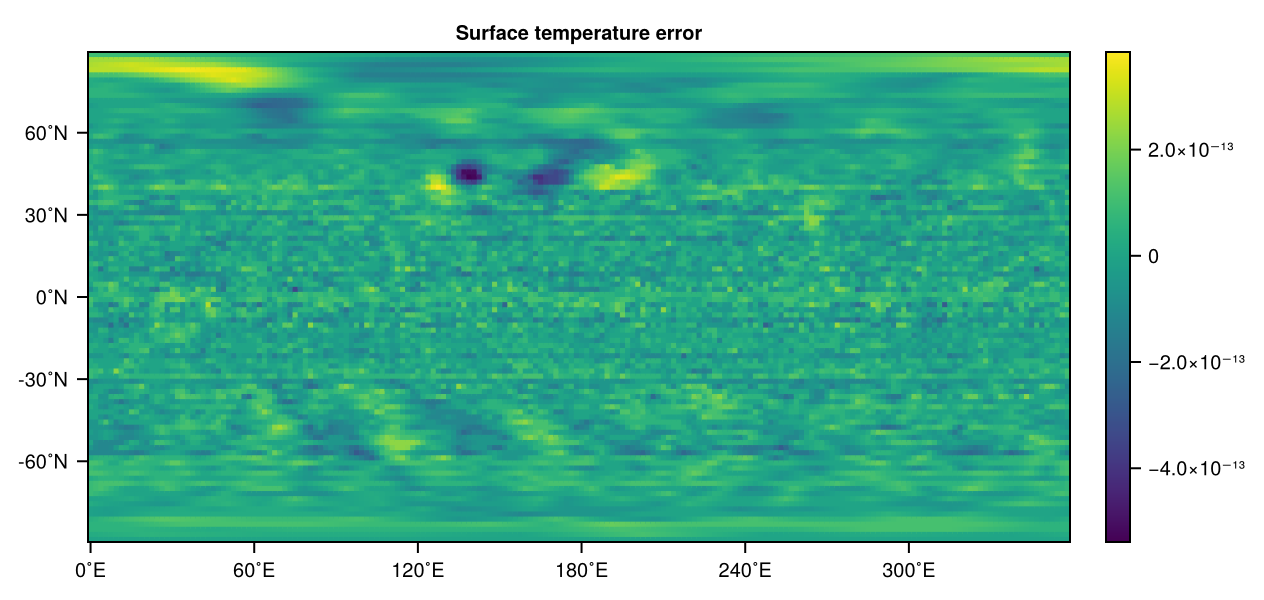

In [30]:
heatmap(temp_reversed_lon_back - temp, title="Surface temperature error")

# Save surface temperature error at each 6h timestep

Each test case is re-run from scratch (40 steps × 6 h = 10 days).  
At every step the surface temperature is captured, inverse-transformed, and compared to the corresponding baseline snapshot.  
Results are saved as `error_matrix` (shape: ngrid × 40, Float64) and `TIMES_H` (hours since start).

In [2]:
"""Run simulation in 6-hourly steps, returning a Vector of surface temperature fields."""
function capture_surface_temp_6h(sim, n_days::Int=10)
    n_steps = n_days * 4
    temps = Vector{Any}(undef, n_steps)
    for i in 1:n_steps
        run!(sim, period=Hour(6))
        temps[i] = deepcopy(sim.variables.grid.temperature[:, end])
    end
    return temps
end

"""Save error_matrix (ngrid × ntimes) and times_h to a NetCDF file."""
function save_error_nc(path, error_matrix, times_h)
    ngrid, nt = size(error_matrix)
    ds = Dataset(path, "c")
    defDim(ds, "gridpoint", ngrid)
    defDim(ds, "time", nt)
    v_t = defVar(ds, "time", Float64, ("time",),
        attrib = OrderedDict("units" => "hours since model start", "long_name" => "forecast time"))
    v_t[:] = times_h
    v_e = defVar(ds, "temperature_error", Float64, ("gridpoint", "time"),
        attrib = OrderedDict("units" => "K",
            "long_name" => "surface temperature error (inverse-transformed minus baseline)"))
    v_e[:, :] = error_matrix
    close(ds)
end

const SAVE_DIR = "/home/h/höver/spatial_paper/SpeedyRuns/saved_errors"
const TIMES_H = Float64.(6:6:240)  # hours since start: 6, 12, …, 240

40-element Vector{Float64}:
   6.0
  12.0
  18.0
  24.0
  30.0
  36.0
  42.0
  48.0
  54.0
  60.0
  66.0
  72.0
  78.0
   ⋮
 174.0
 180.0
 186.0
 192.0
 198.0
 204.0
 210.0
 216.0
 222.0
 228.0
 234.0
 240.0

In [ ]:
# Restore default cos_zenith! (no coordinate transformation) for the baseline re-run
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

# Re-initialize and re-run baseline, capturing surface temperature every 6h
let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=oro, land=lnd, ocean=ocn)
    sim = initialize!(mdl)
    global baseline_temps_6h = capture_surface_temp_6h(sim)
end
println("Baseline: $(length(baseline_temps_6h)) snapshots captured")

In [ ]:
# Override cos_zenith! for rotate-longitude (shift solar hour angle by π)
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc + NF(π)
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=deepcopy(oro), land=deepcopy(lnd), ocean=deepcopy(ocn))
    sim = initialize!(mdl)

    (; vorticity, divergence, temperature, pressure) = sim.variables.prognostic
    (; land, ocean) = sim.variables.prognostic
    for k in eachmatrix(vorticity)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(vorticity, :, k), 180)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(divergence, :, k), 180)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(temperature, :, k), 180)
    end
    for k in eachmatrix(pressure)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(pressure, :, k), 180)
    end
    SpeedyWeather.rotate!(land.soil_temperature, 180)
    SpeedyWeather.rotate!(land.soil_moisture, 180)
    SpeedyWeather.rotate!(land.snow_depth, 180)
    SpeedyWeather.rotate!(ocean.sea_surface_temperature, 180)
    SpeedyWeather.rotate!(ocean.sea_ice_concentration, 180)
    SpeedyWeather.rotate!(mdl.land_sea_mask.mask, 180)
    SpeedyWeather.rotate!(mdl.orography.surface_geopotential, 180)
    SpeedyWeather.rotate!(mdl.orography.orography, 180)
    SpeedyWeather.rotate!(mdl.land.vegetation.high_cover, 180)
    SpeedyWeather.rotate!(mdl.land.vegetation.low_cover, 180)

    temps = capture_surface_temp_6h(sim)

    ngrid, n_steps = length(baseline_temps_6h[1]), length(temps)
    error_matrix = Matrix{Float64}(undef, ngrid, n_steps)
    for i in 1:n_steps
        temp_back = SpeedyWeather.rotate!(deepcopy(temps[i]), -180)
        error_matrix[:, i] = Array(temp_back - baseline_temps_6h[i])
    end

    save_error_nc(joinpath(SAVE_DIR, "error_rotate_lon.nc"), error_matrix, TIMES_H)
    println("Saved error_rotate_lon.nc: $(size(error_matrix))")
end

In [ ]:
# Override cos_zenith! for reverse-latitude (negate sinlat: φ → -φ)
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    sinlat_rev = -sinlat
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat_rev, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=deepcopy(oro), land=deepcopy(lnd), ocean=deepcopy(ocn))
    sim = initialize!(mdl)

    (; vorticity, divergence, temperature, pressure) = sim.variables.prognostic
    (; land, ocean) = sim.variables.prognostic
    for k in eachmatrix(vorticity)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lat)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lat)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lat)
    end
    vorticity .*= -1
    for k in eachmatrix(pressure)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lat)
    end
    SpeedyWeather.reverse!(land.soil_temperature, dims=:lat)
    SpeedyWeather.reverse!(land.soil_moisture, dims=:lat)
    SpeedyWeather.reverse!(land.snow_depth, dims=:lat)
    SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lat)
    SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lat)
    SpeedyWeather.reverse!(mdl.land_sea_mask.mask, dims=:lat)
    SpeedyWeather.reverse!(mdl.orography.surface_geopotential, dims=:lat)
    SpeedyWeather.reverse!(mdl.orography.orography, dims=:lat)
    SpeedyWeather.reverse!(mdl.land.vegetation.high_cover, dims=:lat)
    SpeedyWeather.reverse!(mdl.land.vegetation.low_cover, dims=:lat)

    temps = capture_surface_temp_6h(sim)

    ngrid, n_steps = length(baseline_temps_6h[1]), length(temps)
    error_matrix = Matrix{Float64}(undef, ngrid, n_steps)
    for i in 1:n_steps
        temp_back = reverse!(deepcopy(temps[i]), dims=:lat)
        error_matrix[:, i] = Array(temp_back - baseline_temps_6h[i])
    end

    save_error_nc(joinpath(SAVE_DIR, "error_reverse_lat.nc"), error_matrix, TIMES_H)
    println("Saved error_reverse_lat.nc: $(size(error_matrix))")
end

In [ ]:
# Override cos_zenith! for reverse-longitude (negate solar hour angle: λ → -λ)
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = -(SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc)
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=deepcopy(oro), land=deepcopy(lnd), ocean=deepcopy(ocn))
    sim = initialize!(mdl)

    (; vorticity, divergence, temperature, pressure) = sim.variables.prognostic
    (; land, ocean) = sim.variables.prognostic
    for k in eachmatrix(vorticity)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lon)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lon)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lon)
    end
    vorticity .*= -1
    for k in eachmatrix(pressure)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lon)
    end
    SpeedyWeather.reverse!(land.soil_temperature, dims=:lon)
    SpeedyWeather.reverse!(land.soil_moisture, dims=:lon)
    SpeedyWeather.reverse!(land.snow_depth, dims=:lon)
    SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lon)
    SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lon)
    SpeedyWeather.reverse!(mdl.land_sea_mask.mask, dims=:lon)
    SpeedyWeather.reverse!(mdl.orography.surface_geopotential, dims=:lon)
    SpeedyWeather.reverse!(mdl.orography.orography, dims=:lon)
    mdl.coriolis.f .*= -1
    SpeedyWeather.reverse!(mdl.land.vegetation.high_cover, dims=:lon)
    SpeedyWeather.reverse!(mdl.land.vegetation.low_cover, dims=:lon)

    temps = capture_surface_temp_6h(sim)

    ngrid, n_steps = length(baseline_temps_6h[1]), length(temps)
    error_matrix = Matrix{Float64}(undef, ngrid, n_steps)
    for i in 1:n_steps
        temp_back = reverse!(deepcopy(temps[i]), dims=:lon)
        error_matrix[:, i] = Array(temp_back - baseline_temps_6h[i])
    end

    save_error_nc(joinpath(SAVE_DIR, "error_reverse_lon.nc"), error_matrix, TIMES_H)
    println("Saved error_reverse_lon.nc: $(size(error_matrix))")
end

In [ ]:
using NCDatasets, CairoMakie, Statistics

dir = "/home/h/höver/spatial_paper/SpeedyRuns/saved_errors"
files = [
    ("error_reverse_lat.nc",  "Reverse lat"),
    ("error_reverse_lon.nc",  "Reverse lon"),
    ("error_rotate_lon.nc",   "Rotate lon"),
]

fig = Figure(size=(900, 400))
ax  = Axis(fig[1,1], xlabel="Time step", ylabel="Mean |temperature error|",
           title="Spatial-mean temperature error over time")

for (fname, label) in files
    ds  = Dataset(joinpath(dir, fname))
    err = ds["temperature_error"][:, :]   # gridpoint × time
    close(ds)
    mean_err = vec(mean(abs.(err), dims=1))
    lines!(ax, mean_err, label=label)
end

axislegend(ax, position=:rt)
fig
